Watermarking Analysis on Abstractive Summarization

Introduction:

This notebook applies the LLM watermarking algorithm proposed by Kirchenbauer et al. (2023) to an abstractive summarization setting. The goal is to examine how well the algorithm performs when applied to short, one-sentence summaries generated by BART on the XSum dataset, a more challenging setting than the long-form text generation the algorithm was originally designed for.

Methodology:

I applied the watermarking algorithm of Kirchenbauer et al. (2023) to an abstractive summarization setting using facebook/bart-large-xsum and the XSum test set (600 examples). The watermark processor and detector were imported directly from the authors' official GitHub repository.
I generated two sets of summaries, with and without watermarking, using the 'simple_1' seeding scheme and default hyperparameters (gamma= 0.25, delta= 2.0). The 'selfhash' scheme, recommended by the authors, was found to be incompatible with BART's encoder-decoder architecture due to insufficient decoder context at generation start.

In [ ]:
# Watermarking Analysis on Abstractive Summarization
# Model: BART : facebook/bart-large-xsum
# Dataset: XSum

In [ ]:
# Check GPU
import torch
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/watermarking_analysis", exist_ok=True)

In [ ]:
!git clone https://github.com/jwkirchenbauer/lm-watermarking

Cloning into 'lm-watermarking'...
remote: Enumerating objects: 351, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 351 (delta 32), reused 16 (delta 16), pack-reused 294 (from 2)
Receiving objects: 100% (351/351), 12.01 MiB | 6.55 MiB/s, done.
Resolving deltas: 100% (108/108), done.


In [ ]:
# Requirements
!pip install -q gradio nltk scipy transformers tokenizers rouge_score

  Preparing metadata (setup.py) ... done


In [ ]:
# Tokenizing & model loading
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "facebook/bart-large-xsum"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
print("'facebook/bart-large-xsum' loaded successfully.")


config.json:   0%|          | 0.00/1.51k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/513 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/309 [00:00<?, ?B/s]

'facebook/bart-large-xsum' loaded successfully.


In [ ]:
 # Dataset
from datasets import load_dataset

dataset = load_dataset("EdinburghNLP/xsum", split="test[:600]")
print(f"Loaded {len(dataset)} examples.")
print("\nExample article (first 50 chars):")
print(dataset[0]["document"][:50])

README.md:   0%|          | 0.00/6.42k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

Loaded 600 examples.

Example article (first 50 chars):
Prison Link Cymru had 1,099 referrals in 2015-16 a


In [ ]:
# Watermark requirements
import sys
sys.path.insert(0, "/content/lm-watermarking")
from extended_watermark_processor import WatermarkLogitsProcessor, WatermarkDetector
from transformers import LogitsProcessorList

print("Watermarking classes imported successfully.")



Watermarking classes imported successfully.


In [ ]:
# Summarization function

def summarization(data, model, tokenizer, logits_processor = None):

    max_input = 1024
    max_output = 64
    min_output = 20

    inputs = tokenizer(
        data["document"],
        max_length = max_input,
        truncation = True,
        return_tensors ="pt"
        ).to(device)

    summary_tokenIDs = model.generate(
        inputs["input_ids"],
        min_length = min_output,
        max_length = max_output,
        num_beams = 1, # one token at a time in a single sequence, beam search
        length_penalty = 1.0,
        no_repeat_ngram_size = 4,
        logits_processor = LogitsProcessorList([logits_processor]) if logits_processor else None # WITH & WITHOUT Watermarking
        )

    summary = tokenizer.decode(
        summary_tokenIDs[0],
        skip_special_tokens=True
        )

    return summary
print("Summarization function defined successfully.")

Summarization function defined successfully.


In [ ]:
# Generate summaries WITHOUT watermark
import json
summaries_without_watermark = []

for i, data in enumerate(dataset):
    summary = summarization(data, model, tokenizer)
    summaries_without_watermark.append({
        "id": i,
        "summary": summary
    })

# Save to Drive
save_path = "/content/drive/MyDrive/watermarking_analysis/summaries_without_watermark.json"
with open(save_path, "w") as f:
    json.dump(summaries_without_watermark, f, indent = 3)

print(f"Summaries without watermark are saved to {save_path}")
print(f"\nExample generated summary:")
print(summaries_without_watermark[0]["summary"])

Summaries without watermark are saved to /content/drive/MyDrive/watermarking_analysis/summaries_without_watermark.json

Example generated summary:
The number of people being referred to a charity for help finding housing after being released from prison has risen by more than a third in a year.


In [ ]:
# Watermark processor
watermark_processor = WatermarkLogitsProcessor(
    vocab = list(range(model.config.vocab_size)), # what gets shuffled(list of all BART's token ID)
    gamma = 0.25, # what fraction of vocabulary is green
    delta = 2.0, # adds to the score of every green token
    seeding_scheme = "simple_1" # how the green list is computed at each position
)
print(f"Vocab size: {model.config.vocab_size}")
# print("BART dictionary: ",tokenizer.get_vocab())

In [ ]:
# Generate summaries WITH watermark
summaries_with_watermark = []
for i, data in enumerate(dataset):
    summary = summarization(data, model, tokenizer, logits_processor=watermark_processor)
    summaries_with_watermark.append({
        "id": i,
        "summary": summary
    })

# Save to Drive
save_path = "/content/drive/MyDrive/watermarking_analysis/summaries_with_watermark.json"
with open(save_path, "w") as f:
    json.dump(summaries_with_watermark, f, indent = 3)

print(f"Summaries with watermark are saved to {save_path}")
print(f"\nExample generated summary:")
print(summaries_with_watermark[0]["summary"])


Summaries with watermark are saved to /content/drive/MyDrive/watermarking_analysis/summaries_with_watermark.json

Example generated summary:
More housing should be built for people leaving prison, a charity has said. Zhou Huynhau has said there is a "desperate" need for more accommodation.


In [ ]:
    # Watermark Detector
watermark_detector = WatermarkDetector(
    vocab = list(range(model.config.vocab_size)),
    gamma = 0.25,
    seeding_scheme = "simple_1",
    device = device,
    tokenizer = tokenizer,
    z_threshold = 4.0,
    normalizers = [],
    ignore_repeated_ngrams = True # to skip repeated token sequences
)



In [ ]:
# Load pre-generated summaries from Drive
# This avoids regenerating 600 summaries each session
import json
with open("/content/drive/MyDrive/watermarking_analysis/summaries_without_watermark.json", "r") as f:
    summaries_without_watermark = json.load(f)

with open("/content/drive/MyDrive/watermarking_analysis/summaries_with_watermark.json", "r") as f:
    summaries_with_watermark = json.load(f)

In [ ]:
# Detect Watermark
detection_results = []
for result in summaries_without_watermark:
  detector_output = watermark_detector.detect(result["summary"])
  detection_results.append({
      "id": result["id"],
      "watermarked": False,
      "z_score": detector_output["z_score"],
      "detected": detector_output["prediction"]
  })
print("Detection on non-watermarked summaries is done.")

for result in summaries_with_watermark:
    detector_output = watermark_detector.detect(result["summary"])
    detection_results.append({
        "id": result["id"],
        "watermarked": True,
        "z_score": detector_output["z_score"],
        "detected": detector_output["prediction"]
    })
print("Detection on watermarked summaries is done.")

# Save to drive
result_save_path = "/content/drive/MyDrive/watermarking_analysis/detection_results.json"
with open(result_save_path, "w") as f:
    json.dump(detection_results, f, indent=4)

print(f"Detection result is saved to {result_save_path}")

Detection on non-watermarked summaries is done.
Detection on watermarked summaries is done.
Detection result is saved to /content/drive/MyDrive/watermarking_analysis/detection_results.json


In [ ]:
# Analysis
results_without_watermark = []
results_with_watermark = []

for result in detection_results:
    if result["watermarked"] == False:
        results_without_watermark.append(result)
    else:
        results_with_watermark.append(result)

# True Positive Rate(Detection rate): what % of watermarked summaries were correctly detected?
true_positives = sum(1 for r in results_with_watermark if r["detected"] == True)
true_positives_rate = true_positives / len(results_with_watermark) * 100

# False positive rate: what % of non-watermarked summaries were wrongly detected?
false_positives = sum(1 for r in results_without_watermark if r["detected"] == True)
false_positive_rate = false_positives / len(results_without_watermark) * 100

print(f"Total watermarked summaries: {len(results_with_watermark)}")
print(f"Total non-watermarked summaries: {len(results_without_watermark)}")
print(f"\nTrue_positives rate: {true_positives_rate:.2f}%")
print(f"False positive rate: {false_positive_rate:.2f}%")

Total watermarked summaries: 600
Total non-watermarked summaries: 600

True_positives rate: 9.67%
False positive rate: 0.00%


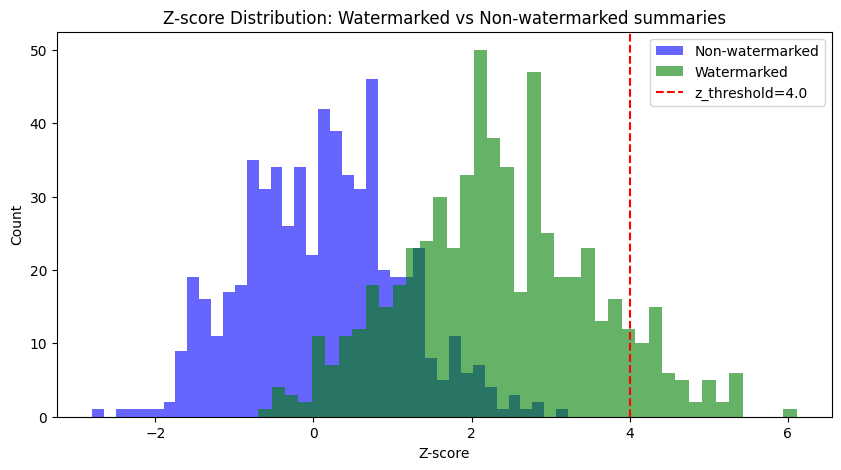

In [ ]:
# Z-score distribution
import matplotlib.pyplot as plt

z_scores_without_watermark = [r["z_score"] for r in results_without_watermark]
z_scores_watermark = [r["z_score"] for r in results_with_watermark]

plt.figure(figsize=(10, 5))
plt.hist(z_scores_without_watermark, bins=40, alpha=0.6, label="Non-watermarked", color="blue")
plt.hist(z_scores_watermark, bins=40, alpha=0.6, label="Watermarked", color="green")
plt.axvline(x=4.0, color="red", linestyle="--", label="z_threshold=4.0") # dashed line
plt.xlabel("Z-score")
plt.ylabel("Count")
plt.title("Z-score Distribution: Watermarked vs Non-watermarked summaries")
plt.legend()
plt.savefig("/content/drive/MyDrive/watermarking_analysis/z_score_distribution.png")
plt.show()

Results: Z-score distribution

The z-score distribution shows a clear separation between watermarked and non-watermarked summaries, watermarked summaries shift toward higher z-scores as expected. However, most watermarked summaries fail to cross the detection threshold of 4.0, as XSum's short one-sentence summaries provide insufficient tokens to accumulate a statistically strong watermark signal.

Threshold 1.0 → Detection rate: 86.2% | False positive rate: 17.7%
Threshold 1.5 → Detection rate: 75.2% | False positive rate: 7.7%
Threshold 2.0 → Detection rate: 60.8% | False positive rate: 3.2%
Threshold 2.5 → Detection rate: 42.3% | False positive rate: 1.2%
Threshold 3.0 → Detection rate: 27.0% | False positive rate: 0.2%
Threshold 3.5 → Detection rate: 17.3% | False positive rate: 0.0%
Threshold 4.0 → Detection rate: 9.8% | False positive rate: 0.0%
Threshold 4.5 → Detection rate: 4.0% | False positive rate: 0.0%
Threshold 5.0 → Detection rate: 2.0% | False positive rate: 0.0%


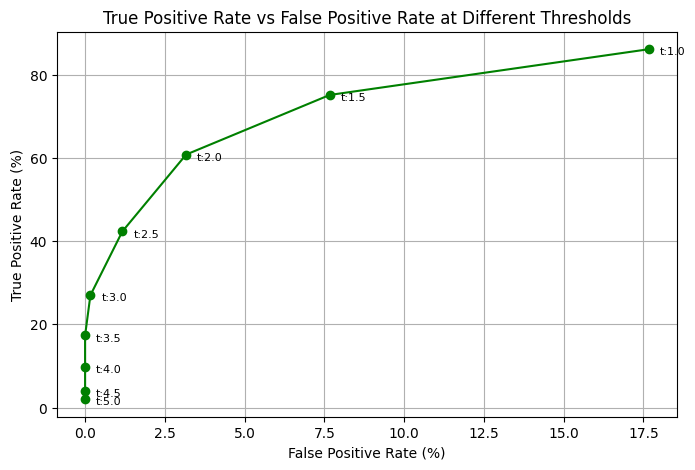

In [ ]:
# Threshold Sensitivity Analysis and Visualization
import numpy as np
thresholds = np.arange(1.0, 5.5, 0.5) #(start, stop, stepSize)
true_p_rate = []
false_p_rate = []

for threshold in thresholds:
    true_p = sum(1 for r in results_with_watermark if r["z_score"] >= threshold) # how many watermarked summaries have a z-score above the current threshold.
    false_p = sum(1 for r in results_without_watermark if r["z_score"] >= threshold) # how many non-watermarked summaries have a z-score above the current threshold.
    true_p_rate.append(true_p / len(results_with_watermark) * 100)
    false_p_rate.append(false_p / len(results_without_watermark) * 100)

    # Just for print
    detection_rate = true_p / len(results_with_watermark) * 100
    fp_rate = false_p / len(results_without_watermark) * 100
    print(f"Threshold {threshold:.1f} → Detection rate: {detection_rate:.1f}% | False positive rate: {fp_rate:.1f}%")

plt.figure(figsize=(8, 5))
plt.plot(false_p_rate, true_p_rate, marker="o", color="green")

# Label each point with its threshold value
for i, threshold in enumerate(thresholds):
    plt.annotate(
        f"t:{threshold}",
        (false_p_rate[i], true_p_rate[i]), #location of the dots
        textcoords="offset points",
        xytext=(8, -4),
        fontsize=8
    )

plt.xlabel("False Positive Rate (%)")
plt.ylabel("True Positive Rate (%)")
plt.title("True Positive Rate vs False Positive Rate at Different Thresholds")
plt.grid(True)
plt.savefig("/content/drive/MyDrive/watermarking_analysis/threshold_tradeoff.png")
plt.show()

Results: Threshold Sensitivity

At the default threshold of 4.0, the detection rate drops to 9.8%. Lowering the threshold improves detection rate significantly, but introduces a tradeoff: false positive rate rises in parallel. At threshold 2.0, detection rate reaches 60.8% with a false positive rate of 3.2%, representing the most practical operating point for short abstractive summarization. This suggests the default threshold of 4.0, designed for longer texts, requires recalibration when applied to XSum-style summaries.

In [ ]:
print(results_without_watermark[0].keys())

dict_keys(['id', 'watermarked', 'z_score', 'detected'])


In [ ]:
print(summaries_without_watermark[0].keys())

dict_keys(['id', 'summary'])


In [ ]:
# Quality analysis, Primary metric: ROUGE
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
rouge_results = []

print("Computing ROUGE scores...")

for i, item in enumerate(summaries_without_watermark):
    reference = dataset[i]["summary"]

    # ROUGE for non-watermarked
    scores_no_wm = scorer.score(reference, item["summary"]) #.score(reference, generated summary)=a dictionary of scores

    # ROUGE for watermarked
    scores_wm = scorer.score(reference, summaries_with_watermark[i]["summary"])

    rouge_results.append({
        "id": i,
        "no_wm_rouge1": scores_no_wm["rouge1"].fmeasure, # F-measure:mean of precision and recall(missing important words & generating irrelevant words)
        "no_wm_rouge2": scores_no_wm["rouge2"].fmeasure,
        "no_wm_rougeL": scores_no_wm["rougeL"].fmeasure,
        "wm_rouge1": scores_wm["rouge1"].fmeasure,
        "wm_rouge2": scores_wm["rouge2"].fmeasure,
        "wm_rougeL": scores_wm["rougeL"].fmeasure,
    })

    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/600 done...")

# Save to Drive
with open("/content/drive/MyDrive/watermarking_analysis/rouge_results.json", "w") as f:
    json.dump(rouge_results, f, indent=4)

print("\nDone.")

Computing ROUGE scores...
  100/600 done...
  200/600 done...
  300/600 done...
  400/600 done...
  500/600 done...
  600/600 done...

Done.


In [ ]:
# Quality analysis, Secondary metric: Perplexity
""" summary -> model -> "how surprising is this text?" """
import torch

def compute_perplexity(text):
    inputs = tokenizer(
        text,
        return_tensors = "pt",
        truncation = True,
        max_length = 1024
    ).to(device)

    with torch.no_grad(): # don't store any data as gradient
        outputs = model(
            **inputs,
            labels = inputs["input_ids"] # correct answers to compare
        )

    perplexity = torch.exp(outputs.loss).item()
    return perplexity

print("Computing perplexity scores...")


perplexity_results = []

for i, item in enumerate(summaries_without_watermark):
    ppl_no_wm = compute_perplexity(item["summary"])
    ppl_wm = compute_perplexity(summaries_with_watermark[i]["summary"])

    perplexity_results.append({
        "id": i,
        "perplexity_without_watermark": ppl_no_wm,
        "perplexity_with_watermark": ppl_wm
    })

    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/600 done...")

# Save to Drive
with open("/content/drive/MyDrive/watermarking_analysis/perplexity_results.json", "w") as f:
    json.dump(perplexity_results, f, indent=4)

print("\nDone.")
print(f"\nExample: {perplexity_results[0]}")

Computing perplexity scores...
  100/600 done...
  200/600 done...
  300/600 done...
  400/600 done...
  500/600 done...
  600/600 done...

Done.

Example: {'id': 0, 'perplexity_without_watermark': 3.746438980102539, 'perplexity_with_watermark': 5.027150630950928}


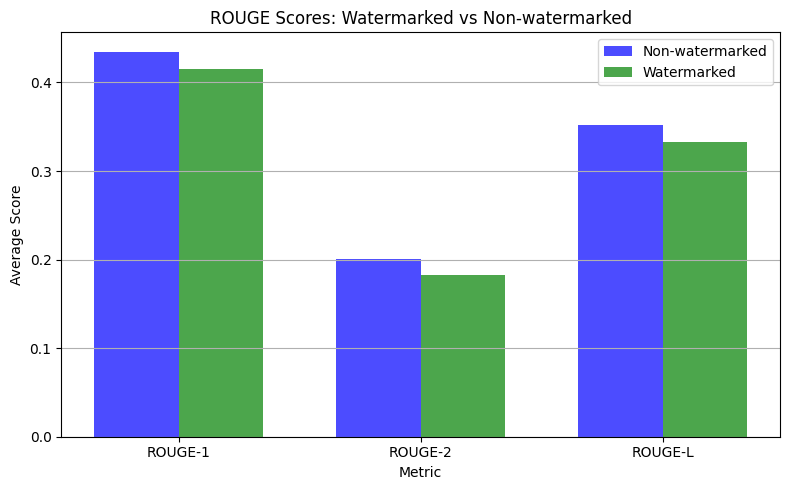

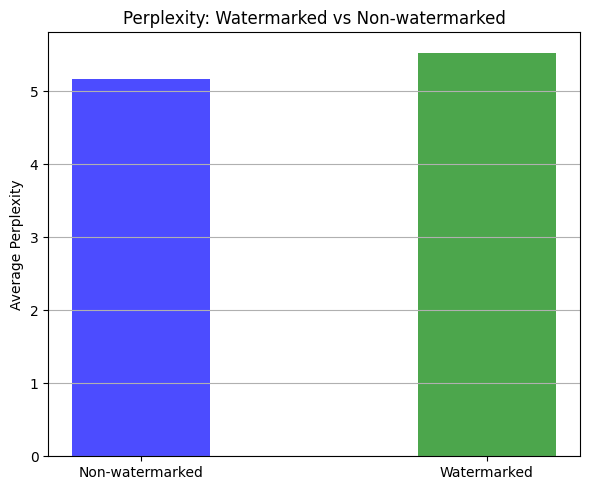

In [ ]:
# Visualizations for ROUGE and perplexity
import json
import matplotlib.pyplot as plt
import numpy as np

# ROUGE
with open("/content/drive/MyDrive/watermarking_analysis/rouge_results.json", "r") as f:
    rouge_results = json.load(f)

metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
no_wm_avgs = [
    sum(r["no_wm_rouge1"] for r in rouge_results) / len(rouge_results),
    sum(r["no_wm_rouge2"] for r in rouge_results) / len(rouge_results),
    sum(r["no_wm_rougeL"] for r in rouge_results) / len(rouge_results)
]
wm_avgs = [
    sum(r["wm_rouge1"] for r in rouge_results) / len(rouge_results),
    sum(r["wm_rouge2"] for r in rouge_results) / len(rouge_results),
    sum(r["wm_rougeL"] for r in rouge_results) / len(rouge_results)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, no_wm_avgs, width, label="Non-watermarked", color="blue", alpha=0.7)
ax.bar(x + width/2, wm_avgs, width, label="Watermarked", color="green", alpha=0.7)

ax.set_xlabel("Metric")
ax.set_ylabel("Average Score")
ax.set_title("ROUGE Scores: Watermarked vs Non-watermarked")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/watermarking_analysis/rouge_comparison.png")
plt.show()

# Perplexity
with open("/content/drive/MyDrive/watermarking_analysis/perplexity_results.json", "r") as f:
    perplexity_results = json.load(f)

avg_ppl_no_wm = sum(r["perplexity_without_watermark"] for r in perplexity_results) / len(perplexity_results)
avg_ppl_wm = sum(r["perplexity_with_watermark"] for r in perplexity_results) / len(perplexity_results)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(
    ["Non-watermarked", "Watermarked"],
    [avg_ppl_no_wm, avg_ppl_wm],
    color=["blue", "green"],
    alpha=0.7,
    width=0.4
)

ax.set_ylabel("Average Perplexity")
ax.set_title("Perplexity: Watermarked vs Non-watermarked")
ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/watermarking_analysis/perplexity_comparison.png")
plt.show()


Results: Quality Analysis, ROUGE and Perplexity

Quality was evaluated using both ROUGE scores and perplexity. ROUGE scores show a small but consistent drop across all three metrics(watermarked summaries score slightly lower than non-watermarked on ROUGE-1, ROUGE-2, and ROUGE-L). Perplexity increases slightly with watermarking, indicating slightly less natural text. Both drops are modest, confirming the paper's claim that watermarking at delta=2.0 does not significantly degrade text quality.

In [ ]:
# Delta sensitivity analysis
import json
from rouge_score import rouge_scorer

deltas = [0.5, 1.0, 3.0, 5.0]
delta_results = {}

for delta in deltas:
  #1.
  new_watermark_processor = WatermarkLogitsProcessor(
      vocab = list(range(model.config.vocab_size)),
      gamma = 0.25,
      delta = delta,
      seeding_scheme = "simple_1"
  )
  new_logits_processor = new_watermark_processor
  #2.
  summaries = []

  for i, data in enumerate(dataset):
    summary = summarization(data, model, tokenizer, logits_processor = new_logits_processor)
    summaries.append({
        "id": i,
        "summary": summary
    })
  #3.
  z_scores = []
  detected = []

  for summary in summaries:
    detector_output = watermark_detector.detect(summary["summary"])
    z_scores.append(detector_output["z_score"])
    detected.append(detector_output["prediction"])
  #4.
  rouge_result = []
  scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

  for i, summary in enumerate(summaries):
    reference = dataset[i]["summary"]
    rouge = scorer.score(reference, summary["summary"])
    rouge_result.append({
        "id": i,
        "rouge1": rouge["rouge1"].fmeasure,
        "rouge2": rouge["rouge2"].fmeasure,
        "rougeL": rouge["rougeL"].fmeasure
    })
  #5.
  delta_results[str(delta)] = {
        "detection_rate": (sum(detected) / len(detected)) * 100, # True=1 , False=0
        "avg_z_score": sum(z_scores) / len(z_scores),
        "avg_rouge1": sum(r["rouge1"] for r in rouge_result) / len(rouge_result),
        "avg_rouge2": sum(r["rouge2"] for r in rouge_result) / len(rouge_result),
        "avg_rougeL": sum(r["rougeL"] for r in rouge_result) / len(rouge_result)
    }

  print(f"  Detection rate: {delta_results[str(delta)]['detection_rate']:.1f}%")
  print(f"  Avg z-score: {delta_results[str(delta)]['avg_z_score']:.2f}")
  print(f"  Avg ROUGE-1: {delta_results[str(delta)]['avg_rouge1']:.3f}")

# Add delta=2.0 results we already have
z_scores_wm = [r["z_score"] for r in detection_results if r["watermarked"] == True]
detected_wm = [r["detected"] for r in detection_results if r["watermarked"] == True]

delta_results["2.0"] = {
    "detection_rate": (sum(detected_wm) / len(detected_wm)) * 100,
    "avg_z_score": sum(z_scores_wm) / len(z_scores_wm),
    "avg_rouge1": sum(r["wm_rouge1"] for r in rouge_results) / len(rouge_result),
    "avg_rouge2": sum(r["wm_rouge2"] for r in rouge_results) / len(rouge_result),
    "avg_rougeL": sum(r["wm_rougeL"] for r in rouge_results) / len(rouge_result)
}

# Save to Drive
with open("/content/drive/MyDrive/watermarking_analysis/delta_results.json", "w") as f:
    json.dump(delta_results, f, indent=4)

print("\nAll delta results saved to Drive.")




  Detection rate: 0.0%
  Avg z-score: 0.62
  Avg ROUGE-1: 0.436
  Detection rate: 1.2%
  Avg z-score: 1.11
  Avg ROUGE-1: 0.432
  Detection rate: 37.0%
  Avg z-score: 3.51
  Avg ROUGE-1: 0.384
  Detection rate: 91.5%
  Avg z-score: 5.96
  Avg ROUGE-1: 0.310

All delta results saved to Drive.


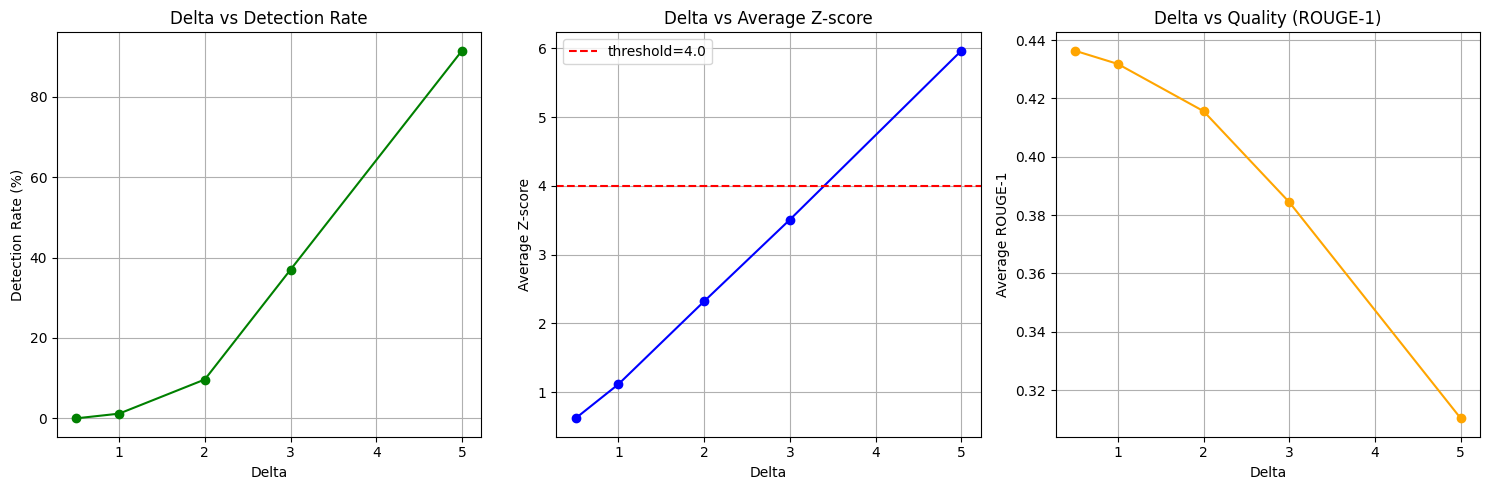

In [ ]:
# Visualization for Delta sensitivity
deltas_sorted = [0.5, 1.0, 2.0, 3.0, 5.0]

detection_rates = [delta_results[str(d)]["detection_rate"] for d in deltas_sorted]
avg_z_scores = [delta_results[str(d)]["avg_z_score"] for d in deltas_sorted]
avg_rouge1 = [delta_results[str(d)]["avg_rouge1"] for d in deltas_sorted]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(deltas_sorted, detection_rates, marker="o", color="green")
axes[0].set_xlabel("Delta")
axes[0].set_ylabel("Detection Rate (%)")
axes[0].set_title("Delta vs Detection Rate")
axes[0].grid(True)

axes[1].plot(deltas_sorted, avg_z_scores, marker="o", color="blue")
axes[1].axhline(y=4.0, color="red", linestyle="--", label="threshold=4.0")
axes[1].set_xlabel("Delta")
axes[1].set_ylabel("Average Z-score")
axes[1].set_title("Delta vs Average Z-score")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(deltas_sorted, avg_rouge1, marker="o", color="orange")
axes[2].set_xlabel("Delta")
axes[2].set_ylabel("Average ROUGE-1")
axes[2].set_title("Delta vs Quality (ROUGE-1)")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/watermarking_analysis/delta_sensitivity.png")
plt.show()

Results: Delta sensitivity

I evaluated four additional delta values (0.5, 1.0, 3.0, 5.0) alongside the default delta=2.0. Results show a clear tradeoff: as delta increases, detection rate and average z-score rise significantly, from 0% detection at delta=0.5 to 91.5% at delta=5.0. However, summary quality measured by ROUGE-1 declines consistently with higher delta, dropping from 0.436 at delta=0.5 to 0.310 at delta=5.0,a 29% reduction. Delta=3.0 offers the most practical balance, achieving 37% detection with a moderate quality cost, while delta=5.0 achieves reliable detection at the expense of noticeably degraded summary quality.

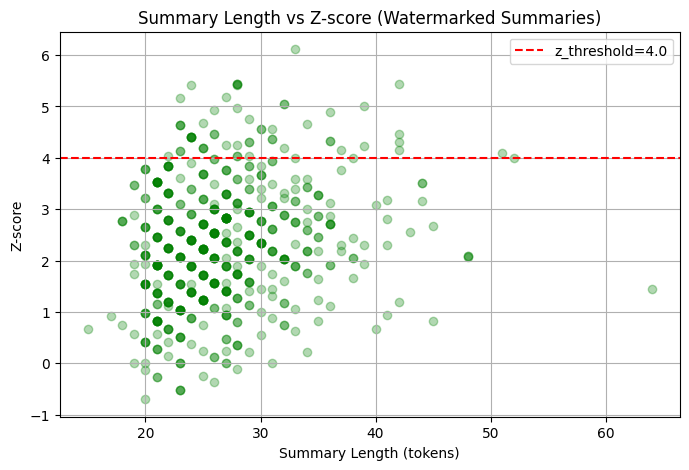

In [ ]:
# Length effect analysis and Visualization
import matplotlib.pyplot as plt

lengths = []
z_scores = []

for i, summary in enumerate(summaries_with_watermark):
  tokens = tokenizer(summary["summary"], return_tensors="pt")
  length = tokens["input_ids"].shape[1] # shape = [batch size, sequence length]

  # get corresponding z-score for watermarked summary i
  z_score = detection_results[i + len(summaries_without_watermark)]["z_score"] # we should skip all the non-watermarked results

  lengths.append(length)
  z_scores.append(z_score)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(lengths, z_scores, alpha=0.3, color="green")
plt.axhline(y=4.0, color="red", linestyle="--", label="z_threshold=4.0")
plt.xlabel("Summary Length (tokens)")
plt.ylabel("Z-score")
plt.title("Summary Length vs Z-score (Watermarked Summaries)")
plt.legend()
plt.grid(True)
plt.savefig("/content/drive/MyDrive/watermarking_analysis/length_effect.png")
plt.show()

Results: Length Effect

I examined whether summary length in tokens correlates with z-score strength. The scatter plot shows that most watermarked summaries regardless of length cluster between z=1 and z=3, with few crossing the detection threshold of 4.0. The relationship between length and z-score is weaker than expected, suggesting that while short text theoretically limits the watermark signal, length alone does not fully explain the low detection rate in this setting.

Conclusion:

This analysis demonstrates that the Kirchenbauer et al. watermarking algorithm, while effective for long-form text generation, faces reliability challenges under short abstractive summarization. At the default threshold of 4.0 and delta=2.0, detection rate on XSum summaries reaches only 9.8%.

Additionally, the selfhash seeding scheme was found incompatible with BART's encoder-decoder architecture, requiring use of the original simple_1 scheme from the paper.

Two practical adjustments improve reliability: lowering the detection threshold to 2.0 recovers 60.8% detection at 3.2% false positive rate, and increasing delta to 5.0 achieves 91.5% detection at the cost of a 29% ROUGE-1 reduction.

These findings suggest that applying LLM watermarking to abstractive summarization requires domain-specific recalibration of both threshold and delta parameters.